In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5],
#                    [3, 0.5], [2, 2], [1, 2.5]])
# y_train = np.array([0, 0, 0, 1, 1, 1])

np.random.seed(42)

# Class 0: 50 points centered at (2, 2)
X_class0 = np.random.randn(50, 2) + np.array([2, 2])
y_class0 = np.zeros(50)


# Class 1: 50 points centered at (4, 4)
X_class1 = np.random.randn(50, 2) + np.array([4, 4])
y_class1 = np.ones(50)

# Combine classes
X_train = np.vstack((X_class0, X_class1))
y_train = np.concatenate((y_class0, y_class1))

# Shuffle the dataset
shuffle_idx = np.random.permutation(len(y_train))
X_train = X_train[shuffle_idx]
y_train = y_train[shuffle_idx]

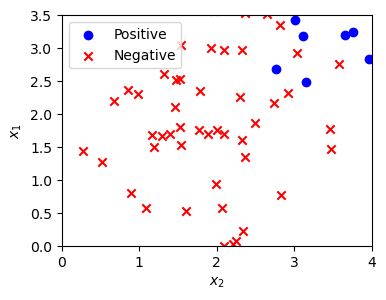

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

positive = y_train == 1
negative = y_train == 0

ax.scatter(X_train[positive, 0], X_train[positive, 1],
           marker='o', c='b', label='Positive')
ax.scatter(X_train[negative, 0], X_train[negative, 1],
           marker='x', c='r', label='Negative')
ax.axis((0, 4, 0, 3.5))
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_2$')
ax.legend()

plt.show()

In [16]:
def sigmoid(z):
    return 1 / (1 + np.e ** -z)

In [17]:
def compute_cost_logistic(X, y, w, b):
    m = len(X)
    cost = 0

    for i in range(m):
        f_wb = sigmoid(w @ X[i] + b)
        loss = -y[i] * np.log(f_wb) - (1-y[i]) * np.log(1 - f_wb)
        cost += loss

    return cost / m

In [18]:
def compute_gradient_logistic(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0

    for i in range(m):
        f_wb_i = sigmoid(w @ X[i] + b)
        err_i = f_wb_i - y[i]
        dj_dw += err_i * X[i]
        dj_db += err_i
        
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [19]:
compute_gradient_logistic(X_train, y_train, (2, 3), 1)

(array([0.93160127, 0.96375557]), np.float64(0.49961143230200605))

In [20]:
def compute_gradient_descent_logistic(X, y, n_iter):
    w = np.zeros_like(X[0])
    b = 0
    alpha = 0.5
    for _ in range(n_iter):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
    
    return w, b

In [21]:
w, b = compute_gradient_descent_logistic(X_train, y_train, 10000)
m = len(X_train)
cost = compute_cost_logistic(X_train, y_train, w, b)
print("Cost", cost)
correct = 0
wrong = 0
for i in range(m):
    f_wb_i = sigmoid(w @ X_train[i] + b)
    y_hat_i = 1.0 if f_wb_i >= 0.5 else 0.0
    y_i = y_train[i]
    if y_hat_i == y_i:
        correct += 1
    else:
        wrong += 1
    print(f"Predict: {y_hat_i}, Actual: {y_i}")

print("Correct", correct, "Wrong", wrong)

Cost 0.110817634818341
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, Actual: 0.0
Predict: 0.0, Actual: 0.0
Predict: 1.0, Actual: 1.0
Predict: 0.0, A